### 1. Load the dataset and encode class labels

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# The wdbc.data file has no header, so we define column names ourselves
columns = ['id', 'diagnosis'] + [f'feature_{i}' for i in range(1, 31)]

df = pd.read_csv("wdbc.data", header=None, names=columns)
df = df.drop('id', axis=1)   # id column is not useful for prediction
df.head()

,diagnosis,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [29]:
# Encode diagnosis: M (Malignant) = 1, B (Benign) = 0
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])
print("Classes:", le.classes_)   # ['B' 'M'] -> B=0, M=1
df.head()

Classes: ['B' 'M']


,diagnosis,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 2. Exploratory Data Analysis

In [30]:
# Class distribution
df['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

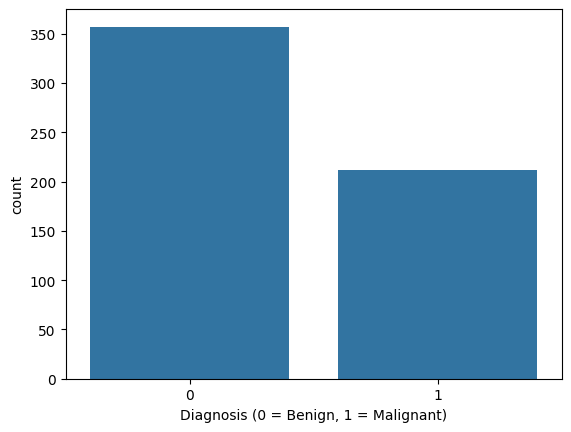

In [31]:
sns.countplot(x='diagnosis', data=df)
plt.xlabel("Diagnosis (0 = Benign, 1 = Malignant)")
plt.show()

In [32]:
# Correlation of first few features with the target (to keep output short)
df.iloc[:, :6].corr()

,diagnosis,feature_1,feature_2,feature_3,feature_4,feature_5
diagnosis,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560
feature_1,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581
feature_2,0.415185,0.323782,1.000000,0.329533,0.321086,-0.023389
feature_3,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278
feature_4,0.708984,0.987357,0.321086,0.986507,1.000000,0.177028
feature_5,0.358560,0.170581,-0.023389,0.207278,0.177028,1.000000


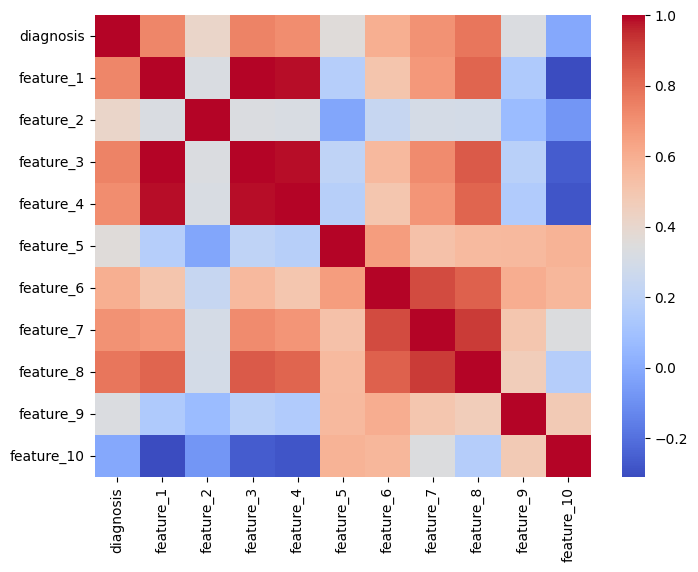

In [33]:
# Heatmap of correlation among first 10 features
plt.figure(figsize=(8,6))
sns.heatmap(df.iloc[:, :11].corr(), annot=False, cmap='coolwarm')
plt.show()

### 3. Split the dataset into training and testing sets (80-20)

In [34]:
from sklearn.model_selection import train_test_split

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (455, 30)
Testing set size: (114, 30)


### 4. Train a Decision Tree classifier

In [35]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### 5. Define hyperparameter search space (Decision Tree)

In [36]:
dt_param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

### 6. Perform 5-Fold Cross-Validation for Decision Tree

In [37]:
from sklearn.model_selection import GridSearchCV

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                        dt_param_grid, cv=5, scoring='accuracy')
dt_grid.fit(X_train, y_train)

print("Best Decision Tree params:", dt_grid.best_params_)
print("Best CV accuracy: %.4f" % dt_grid.best_score_)

Best Decision Tree params: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV accuracy: 0.9429


### 7. Train Decision Tree with the best hyperparameters

In [39]:
best_dt = dt_grid.best_estimator_
dt_pred = best_dt.predict(X_test)

### 8. Train a Random Forest classifier

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 9. Define hyperparameter search space (Random Forest)

In [48]:
rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True]
}

### 10. Perform 5-Fold Cross-Validation for Random Forest

In [49]:
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                        rf_param_grid, cv=5, scoring='accuracy')
rf_grid.fit(X_train, y_train)

print("Best Random Forest params:", rf_grid.best_params_)
print("Best CV accuracy: %.4f" % rf_grid.best_score_)

Best Random Forest params: {'bootstrap': True, 'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 100}
Best CV accuracy: 0.9604


### 11. Train Random Forest with the best hyperparameters

In [50]:
best_rf = rf_grid.best_estimator_
rf_pred = best_rf.predict(X_test)

### 12. 5-Fold Cross-Validation Accuracy Comparison

In [51]:
from sklearn.model_selection import cross_val_score

dt_cv_scores = cross_val_score(best_dt, X, y, cv=5, scoring='accuracy')
rf_cv_scores = cross_val_score(best_rf, X, y, cv=5, scoring='accuracy')

cv_table = pd.DataFrame({
    'Fold 1': [dt_cv_scores[0], rf_cv_scores[0]],
    'Fold 2': [dt_cv_scores[1], rf_cv_scores[1]],
    'Fold 3': [dt_cv_scores[2], rf_cv_scores[2]],
    'Fold 4': [dt_cv_scores[3], rf_cv_scores[3]],
    'Fold 5': [dt_cv_scores[4], rf_cv_scores[4]],
}, index=['Decision Tree', 'Random Forest'])

cv_table['Average'] = cv_table.mean(axis=1)
cv_table

,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Average
Decision Tree,0.903509,0.912281,0.956140,0.938596,0.955752,0.933256
Random Forest,0.921053,0.938596,0.982456,0.973684,0.982301,0.959618


### 13. Evaluation Metrics — Decision Tree

In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))

Accuracy : 0.9649122807017544
Precision: 1.0
Recall   : 0.9069767441860465
F1 Score : 0.9512195121951219


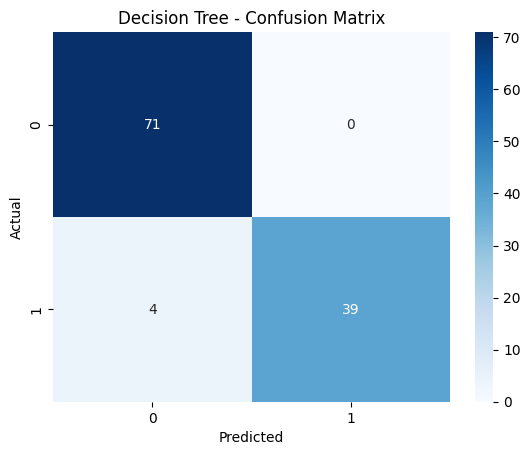

In [53]:
sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 14. Evaluation Metrics — Random Forest

In [54]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

Accuracy : 0.9649122807017544
Precision: 0.975609756097561
Recall   : 0.9302325581395349
F1 Score : 0.9523809523809523


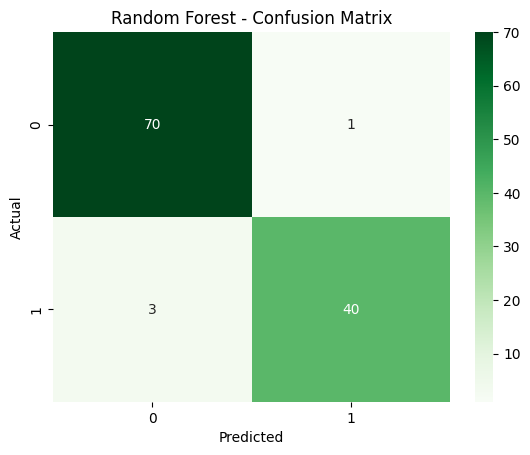

In [55]:
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 15. ROC Curve and AUC

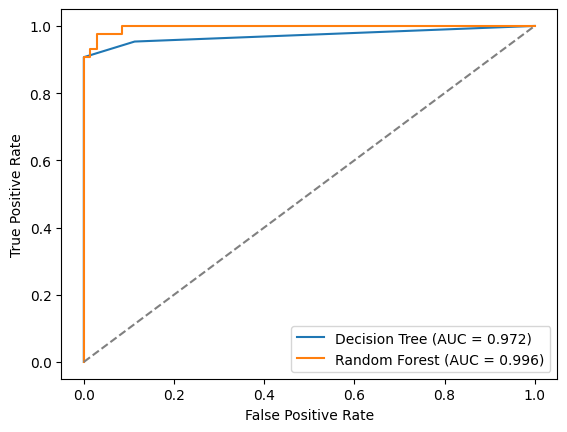

In [56]:
from sklearn.metrics import roc_curve, roc_auc_score

dt_probs = best_dt.predict_proba(X_test)[:, 1]
rf_probs = best_rf.predict_proba(X_test)[:, 1]

dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

plt.plot(dt_fpr, dt_tpr, label=f"Decision Tree (AUC = {roc_auc_score(y_test, dt_probs):.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_probs):.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### 16. Effect of Tree Depth on Overfitting (Decision Tree)

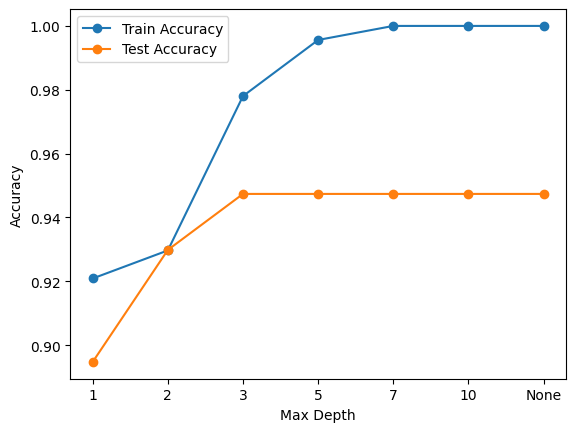

In [57]:
depths = [1, 2, 3, 5, 7, 10, None]
train_acc = []
test_acc = []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_acc.append(tree.score(X_train, y_train))
    test_acc.append(tree.score(X_test, y_test))

depth_labels = [str(d) for d in depths]
plt.plot(depth_labels, train_acc, marker='o', label='Train Accuracy')
plt.plot(depth_labels, test_acc, marker='o', label='Test Accuracy')
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()